# K-means Clustering:
The first clustering method we used is K-Means clustering on a placement dataset to group students based on their academic and skill-related features. The goal is to see what types of students exist and how those groups relate to placement outcome. Instead of predicting placement, we used clustering to find patterns in the data. The idea was to group similar students together and then see how those groups perform in terms of placement.

In [34]:
# Uploading the data and importing the needed libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


df = pd.read_csv("full_dataset.csv")   
print(df.head())

   Student_ID  Age  Gender  Degree Branch  CGPA  Internships  Projects  \
0        1048   22  Female  B.Tech    ECE  6.29            0         3   
1       37820   20  Female     BCA    ECE  6.05            1         4   
2       49668   22    Male     MCA     ME  7.22            1         4   
3       19467   22    Male     MCA     ME  7.78            2         4   
4       23094   20  Female  B.Tech     ME  7.63            1         4   

   Coding_Skills  Communication_Skills  Aptitude_Test_Score  \
0              4                     6                   51   
1              6                     8                   59   
2              6                     6                   58   
3              6                     6                   90   
4              6                     5                   79   

   Soft_Skills_Rating  Certifications  Backlogs Placement_Status  
0                   5               1         3       Not Placed  
1                   8               2     

For clustering, we only used the features related to student performance, like CGPA, internships, projects, certifications, and communication skills. We did not include placement because clustering is unsupervised and then we scaled the data using StandardScaler. This is important because K-Means is based on distance, so all variables need to be on the same scale.

In [27]:
X = df[['CGPA', 'Internships', 'Projects', 'Certifications', 'Communication_Skills']]


# We need to scale the features before clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


### Elbow Method

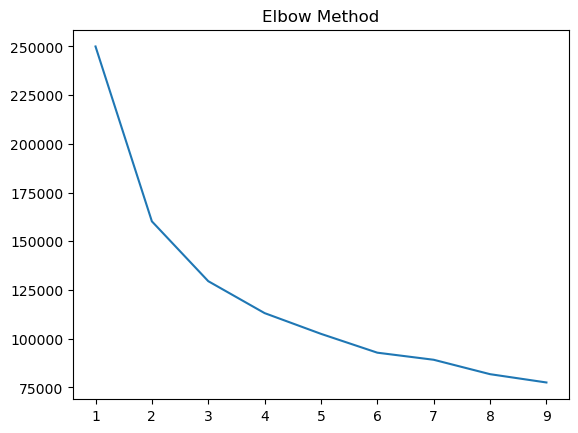

In [28]:
# Decided to use the elbow method to help choose k
wcss = []

for i in range(1, 10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 10), wcss)
plt.title("Elbow Method")
plt.show()

### Silhouette Score

In [8]:
for i in range(2, 6):
    kmeans = KMeans(n_clusters=i, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    print(i, silhouette_score(X_scaled, labels))

2 0.2976502885759805
3 0.25369464868766545
4 0.23776294172148527
5 0.2442162426454156


To decide how many clusters to use, we looked at both the elbow method and silhouette scores. The elbow plot showed a large drop from k = 1 to k = 3, then leveled off, suggesting 2 to 3 clusters would work. The highest silhouette score was at k = 2, meaning it had the strongest separation, but we also tested k = 3 to see if it gave better insight. When we compared the results, k = 3 gave clearer and more meaningful groupings, separating students into low, medium, and high-performing groups. When we tested k = 4, it added an extra cluster without much new insight and made the results harder to interpret, so we chose k = 3.

### Final Model

In [32]:
# Fitting the final kmeans model
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

df.groupby('Cluster')[['CGPA','Internships','Projects','Certifications','Communication_Skills']].mean()

# Comparing the clusters to placement outcomes
pd.crosstab(df['Cluster'], df['Placement_Status'], normalize='index')

Placement_Status,Not Placed,Placed
Cluster,,
0,0.989146,0.010854
1,0.581884,0.418116
2,0.321762,0.678238


After creating the clusters, we compared them to placement outcomes to see if the groups were meaningful. Even though placement was not used in the clustering process, we used it afterward as an external validation measure. The results show a clear pattern. Cluster 0 has almost no students placed (about 1%). Cluster 1 has a moderate placement rate (around 42%). Cluster 2 has the highest placement rate (about 68%). This shows that the clustering grouped students in a meaningful way. Stronger clusters have higher placement rates, while weaker clusters have very low placement. This confirms that the clusters capture real differences in student performance and placement outcomes.

### Cluster Analysis and Visual Results

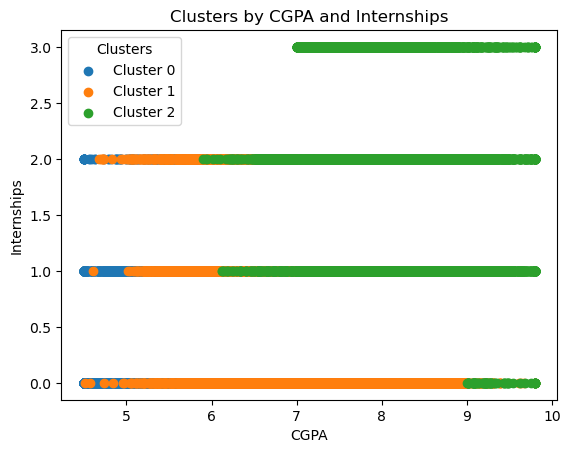

In [12]:
for cluster in df['Cluster'].unique():
    subset = df[df['Cluster'] == cluster]
    plt.scatter(subset['CGPA'], subset['Internships'], label=f"Cluster {cluster}")

plt.xlabel("CGPA")
plt.ylabel("Internships")
plt.title("Clusters by CGPA and Internships")

plt.legend(title="Clusters")
plt.show()

We created a scatterplot using CGPA and internships to visualize the clusters, where each point represents a student and the colors show which cluster they belong to. The plot shows a clear pattern, with lower CGPA students mostly in Cluster 0, higher CGPA students in Cluster 2, and Cluster 1 in between. Internships only take a few values so the points appear in horizontal lines, but the separation based on CGPA is still very clear. Overall, the plot supports the clustering results and shows a progression from lower-performing to higher-performing students.

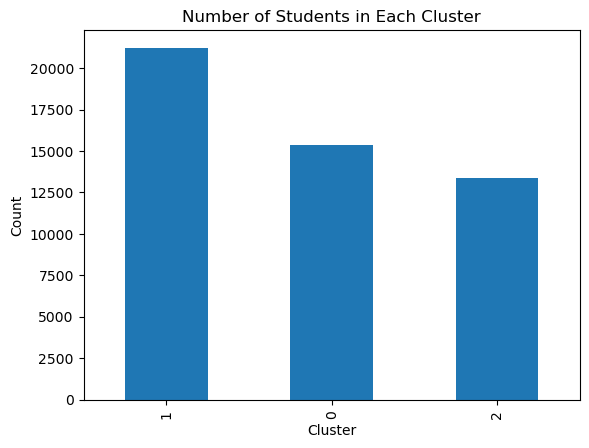

In [22]:
df['Cluster'].value_counts().plot(kind='bar')
plt.title("Number of Students in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.show()

We created a bar chart to show the number of students in each cluster. The clusters are not exactly equal in size, which is expected since clustering groups students based on similarity rather than forcing equal group sizes. However, they are still reasonably balanced, which suggests the model produced stable and meaningful groupings.

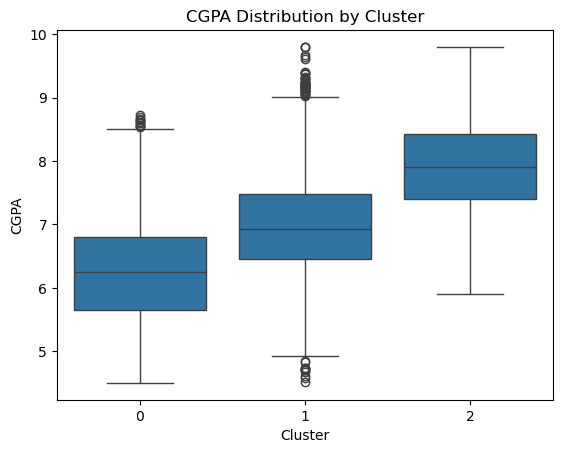

In [23]:
import seaborn as sns

sns.boxplot(x='Cluster', y='CGPA', data=df)
plt.title("CGPA Distribution by Cluster")
plt.show()

We created a boxplot to show the distribution of CGPA across each cluster. The plot shows a clear difference between the groups, with Cluster 0 having the lowest CGPA, Cluster 1 in the middle, and Cluster 2 having the highest. This confirms that CGPA is one of the main factors separating the clusters and supports the overall clustering results.

In [15]:
df.groupby('Cluster')[['CGPA','Internships','Projects','Certifications','Communication_Skills']].mean()

,CGPA,Internships,Projects,Certifications,Communication_Skills
Cluster,,,,,
0,6.227824,0.261406,2.724685,0.990121,5.511439
1,6.967782,0.530798,3.810123,1.997785,5.478910
2,7.947700,1.747070,4.779022,2.422844,5.519746


We looked at the average values of each feature in each cluster to understand what they represent. Cluster 0 has the lowest CGPA, the fewest internships, and fewer projects and certifications. This suggests it represents lower-performing students. Cluster 1 is more in the middle across all features, so it represents average students. Cluster 2 has the highest CGPA, the most internships, and the highest number of projects and certifications. This suggests it represents high-performing students. Communication skills are very similar across all clusters, which means they are not a major factor separating the groups.

### Important Findings

The most important finding is that the clusters strongly align with placement outcomes. Students in the strongest cluster have the highest placement rate, while students in the weakest cluster have almost none. This shows that academic performance and experience, especially CGPA and internships, play a major role in placement success. Another interesting finding is that communication skills are very similar across all clusters, which suggests they are not a key factor in separating student groups.

### Conclusion

Overall, K-Means clustering worked well for this dataset. It grouped students into meaningful categories, and those groups clearly relate to placement outcomes. The results show that stronger academic and experience profiles are associated with higher placement success.